## Lab 2 - Animal Image classification with CNN (due 17.04.2026)

### 0.1 Imports

In [38]:
import zipfile, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt

### 0.2 Read zip and laod dataset

In [2]:
BASE_DIR = Path.cwd().parent
zip_path = BASE_DIR / "data/lab_2/data.zip"
input_data_extraction_path = BASE_DIR / "data/lab_2/"

if not (input_data_extraction_path / "animals_dataset").exists():
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(input_data_extraction_path)
else:
    print(f"{input_data_extraction_path / 'animals_dataset'} already there!")


/Users/sunsosun/Desktop/mini/ann/data/lab_2/animals_dataset already there!


In [3]:
src = input_data_extraction_path / "data"

if src.exists():    
    src.rename(input_data_extraction_path / "animals_dataset")

### 0.3. Setup train, test dirs

In [4]:
train_dir = input_data_extraction_path / "animals_dataset/train"
test_dir = input_data_extraction_path / "animals_dataset/test"


### 0.4. Basic EDA for train set (here i assume that test set is analogical and we dont have access for it)

Classes in train set: ['bears', 'elephants']
Train set class counts: {'bears': 200, 'elephants': 200}


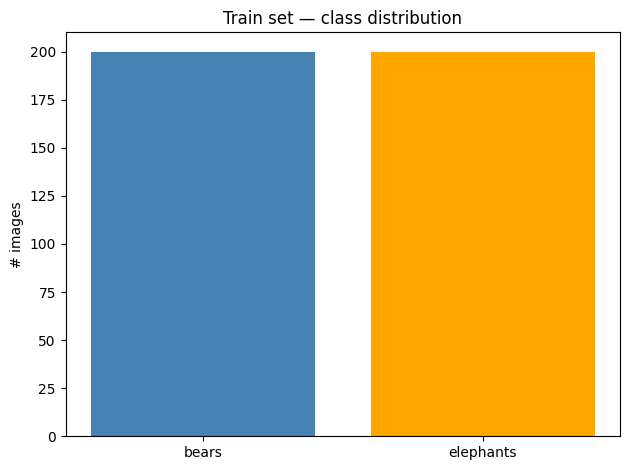

In [6]:
# Check distro of classes
classes = [d.name for d in train_dir.iterdir() if d.is_dir()]
print(f"Classes in train set: {classes}")

counts = {cls: len(list((train_dir / cls).iterdir())) for cls in classes}
print(f"Train set class counts: {counts}")

fig, ax = plt.subplots()
ax.bar(counts.keys(), counts.values(), color=["steelblue", "orange"])
ax.set_title("Train set — class distribution")
ax.set_ylabel("# images")
plt.tight_layout()
plt.show()

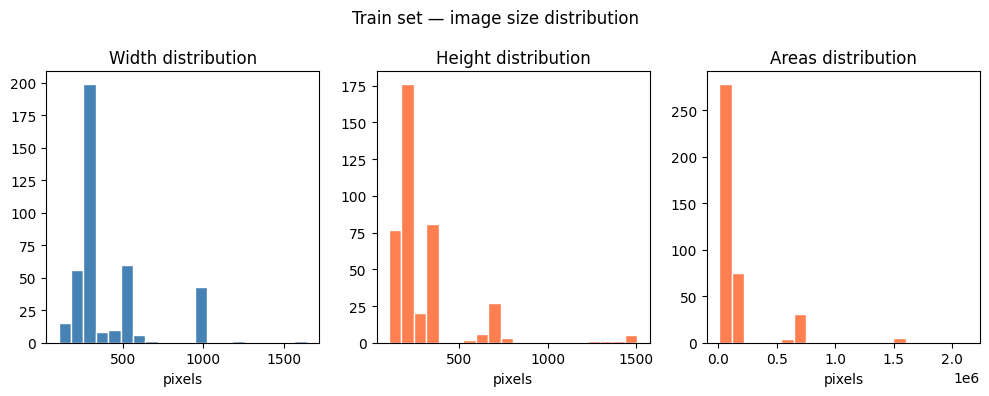

Width  — min: 104, max: 1638, mean: 395
Height — min: 104, max: 1506, mean: 289
Area — min: 10816, max: 2129400, mean: 161169


In [9]:
# Check img dimensions
widths, heights, areas = [], [], []
for cls in classes:
    for img_path in (train_dir / cls).iterdir():
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            areas.append(w*h)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].hist(widths, bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Width distribution")
axes[0].set_xlabel("pixels")

axes[1].hist(heights, bins=20, color="coral", edgecolor="white")
axes[1].set_title("Height distribution")
axes[1].set_xlabel("pixels")

axes[2].hist(areas, bins=20, color="coral", edgecolor="white")
axes[2].set_title("Areas distribution")
axes[2].set_xlabel("pixels")

plt.suptitle("Train set — image size distribution")
plt.tight_layout()
plt.show()

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"Area — min: {min(areas)}, max: {max(areas)}, mean: {np.mean(areas):.0f}")

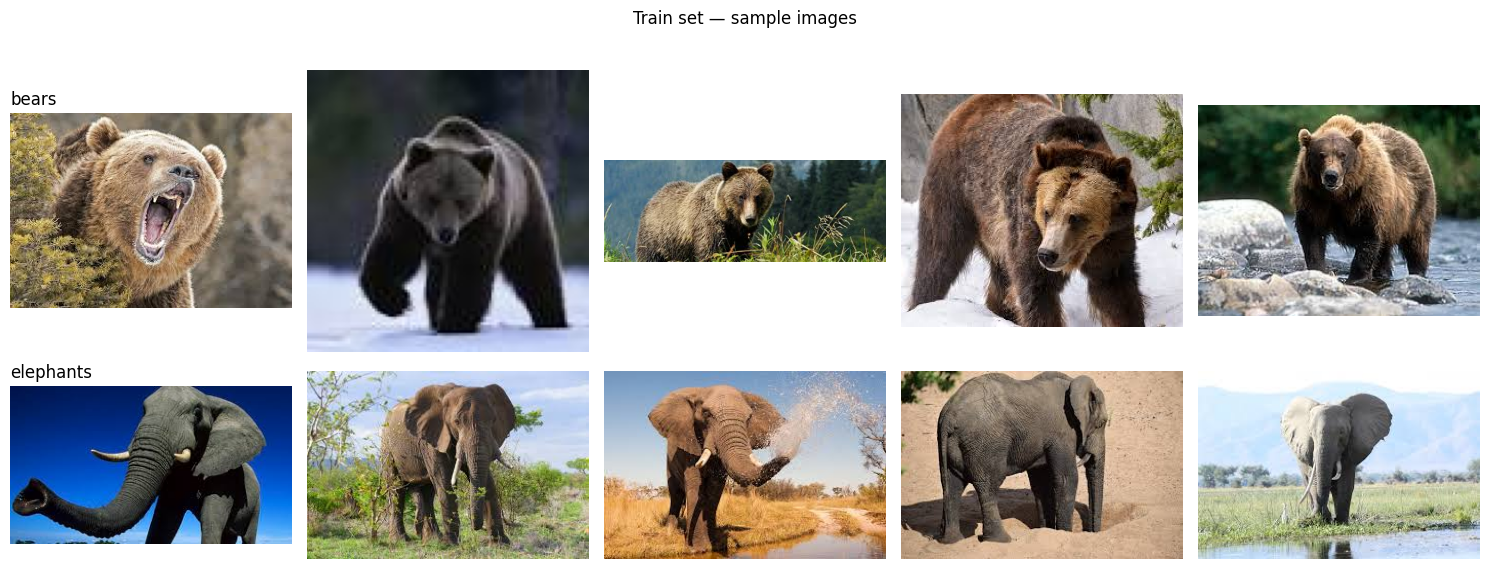

In [11]:
# Check images themselves
n_samples = 5
fig, axes = plt.subplots(len(classes), n_samples, figsize=(3 * n_samples, 3 * len(classes)))

for row, cls in enumerate(classes):
    imgs = sorted((train_dir / cls).iterdir())[:n_samples]
    for col, img_path in enumerate(imgs):
        ax = axes[row][col]
        ax.imshow(Image.open(img_path))
        ax.axis("off")
        if col == 0:
            ax.set_title(cls, fontsize=12, loc="left")
            
plt.suptitle("Train set — sample images", y=1.02)
plt.tight_layout()
plt.show()

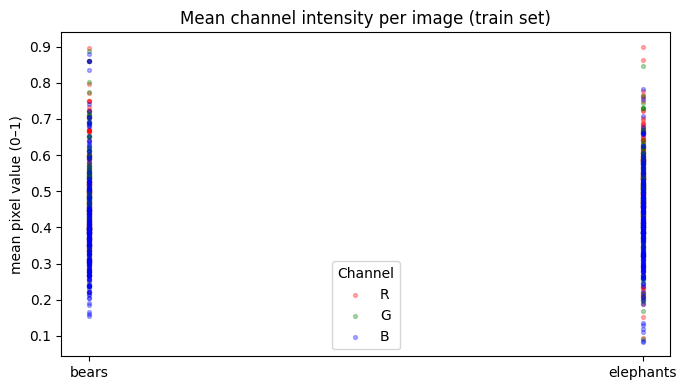

In [13]:
# pixels
TARGET_SIZE = (128, 128)

mean_pixels = {}
for cls in classes:
    pixels = []
    for img_path in (train_dir / cls).iterdir():
        arr = np.array(Image.open(img_path).convert("RGB").resize(TARGET_SIZE)) / 255.0
        pixels.append(arr.mean(axis=(0, 1)))   # mean R, G, B per image
    mean_pixels[cls] = np.array(pixels)

fig, ax = plt.subplots(figsize=(7, 4))
for i, (cls, vals) in enumerate(mean_pixels.items()):
    for c, color, label in zip(range(3), ["red", "green", "blue"], ["R", "G", "B"]):
        ax.scatter([i] * len(vals), vals[:, c], alpha=0.3, color=color, s=8,
                   label=label if i == 0 else "")
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes)
ax.set_title("Mean channel intensity per image (train set)")
ax.set_ylabel("mean pixel value (0–1)")
ax.legend(title="Channel")
plt.tight_layout()
plt.show()


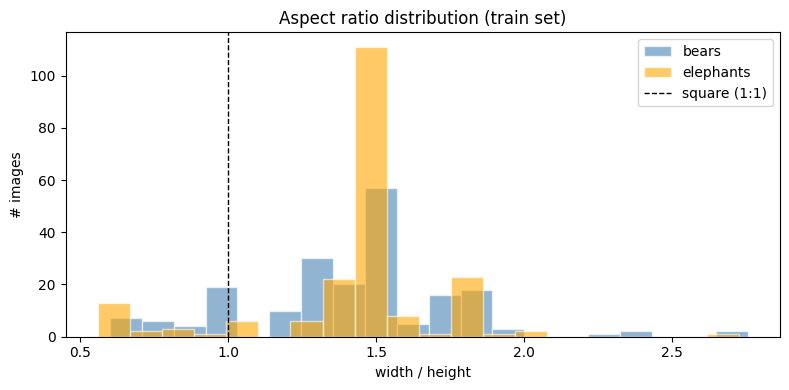

In [15]:
# Ratio width/height
fig, ax = plt.subplots(figsize=(8, 4))
for cls, color in zip(classes, ["steelblue", "orange"]):
    ratios = []
    for img_path in (train_dir / cls).iterdir():
        with Image.open(img_path) as img:
            w, h = img.size
            ratios.append(w / h)
    ax.hist(ratios, bins=20, alpha=0.6, label=cls, color=color, edgecolor="white")

ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="square (1:1)")
ax.set_title("Aspect ratio distribution (train set)")
ax.set_xlabel("width / height")
ax.set_ylabel("# images")
ax.legend()
plt.tight_layout()
plt.show()


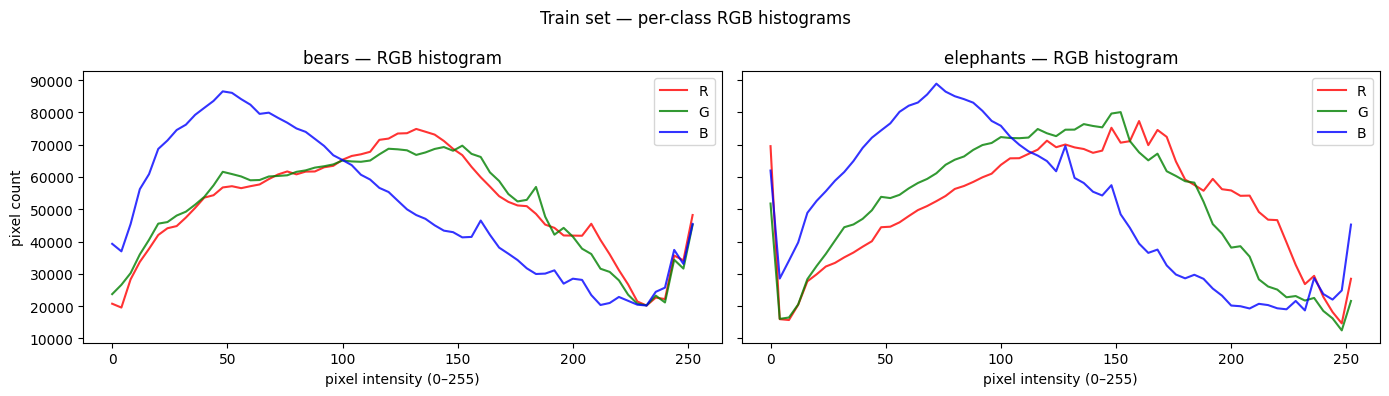

In [20]:
# RGB per class
fig, axes = plt.subplots(1, len(classes), figsize=(7 * len(classes), 4), sharey=True)

for ax, cls in zip(axes, classes):
    r_all, g_all, b_all = [], [], []
    for img_path in (train_dir / cls).iterdir():
        arr = np.array(Image.open(img_path).convert("RGB").resize(TARGET_SIZE))
        r_all.append(arr[:, :, 0].ravel())
        g_all.append(arr[:, :, 1].ravel())
        b_all.append(arr[:, :, 2].ravel())

    r_all = np.concatenate(r_all)
    g_all = np.concatenate(g_all)
    b_all = np.concatenate(b_all)

    bins = np.arange(0, 257, 4)
    ax.plot(bins[:-1], np.histogram(r_all, bins=bins)[0], color="red",   alpha=0.8, label="R")
    ax.plot(bins[:-1], np.histogram(g_all, bins=bins)[0], color="green", alpha=0.8, label="G")
    ax.plot(bins[:-1], np.histogram(b_all, bins=bins)[0], color="blue",  alpha=0.8, label="B")
    ax.set_title(f"{cls} — RGB histogram")
    ax.set_xlabel("pixel intensity (0–255)")
    ax.legend()

axes[0].set_ylabel("pixel count")
plt.suptitle("Train set — per-class RGB histograms")
plt.tight_layout()
plt.show()


After EDA I would like to do transformations of images for normalization before feeding to CNNs but tasks explicitely state which transformations to do in each, so I will do them gradually within the tasks 

### Q1. Baseline Linear Classifier (Flatten → Linear → Softmax).
Resize images to 128×128, normalize RGB, flatten, and train a single Linear layer → num_classes with CrossEntropyLoss. Report top‑1 accuracy on the validation split.    

In [35]:
# configs for splitting and img normalization
SEED = 42
IMG_SIZE = 128 # resize img to 128*128
BATCH_SIZE = 64
VAL_FRAC = 0.2
NUM_CLASSES = 2

# from ImageNet dataset stats
MEAN_LIST = [0.485, 0.456, 0.406] 
STD_LIST = [0.229, 0.224, 0.225]

# configs for training
EPOCHS = 10
LR = 1e-3

In [25]:
torch.manual_seed(SEED)

# transformation pipeline for input
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN_LIST, std=STD_LIST),
])

In [26]:
# get datasets
full_train_ds = ImageFolder(root=str(train_dir), transform=transform)
test_ds = ImageFolder(root=str(test_dir), transform=transform)

# split full train to train and val
n_val = int(len(full_train_ds) * VAL_FRAC)
n_train = len(full_train_ds) - n_val

train_ds, val_ds = random_split(full_train_ds, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

# loaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [32]:
class LinearClassifier(nn.Module):
    def __init__(self, img_size=IMG_SIZE, num_classes=NUM_CLASSES):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(3*img_size*img_size, num_classes)
    def forward(self,x):
        return self.linear(self.flatten(x))

In [34]:
model = LinearClassifier()
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

LinearClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=49152, out_features=2, bias=True)
)
Parameters: 98,306


In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += len(labels)
    return total_loss / total, correct / total

In [37]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader, train=False)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"train loss {tr_loss:.4f}  acc {tr_acc:.4f} | "
          f"val loss {vl_loss:.4f}  acc {vl_acc:.4f}")


Epoch  1/10 | train loss 6.0049  acc 0.5719 | val loss 6.7385  acc 0.5750
Epoch  2/10 | train loss 4.4554  acc 0.6969 | val loss 5.2709  acc 0.6250
Epoch  3/10 | train loss 3.2559  acc 0.7562 | val loss 8.1238  acc 0.5875
Epoch  4/10 | train loss 2.5902  acc 0.7688 | val loss 3.5813  acc 0.7125
Epoch  5/10 | train loss 1.7337  acc 0.8375 | val loss 4.3169  acc 0.6625
Epoch  6/10 | train loss 1.2482  acc 0.8750 | val loss 2.1971  acc 0.7750
Epoch  7/10 | train loss 0.7860  acc 0.8844 | val loss 3.8009  acc 0.6750
Epoch  8/10 | train loss 0.2627  acc 0.9406 | val loss 2.3216  acc 0.7375
Epoch  9/10 | train loss 0.1895  acc 0.9531 | val loss 2.3872  acc 0.7000
Epoch 10/10 | train loss 0.2287  acc 0.9531 | val loss 3.0421  acc 0.6875


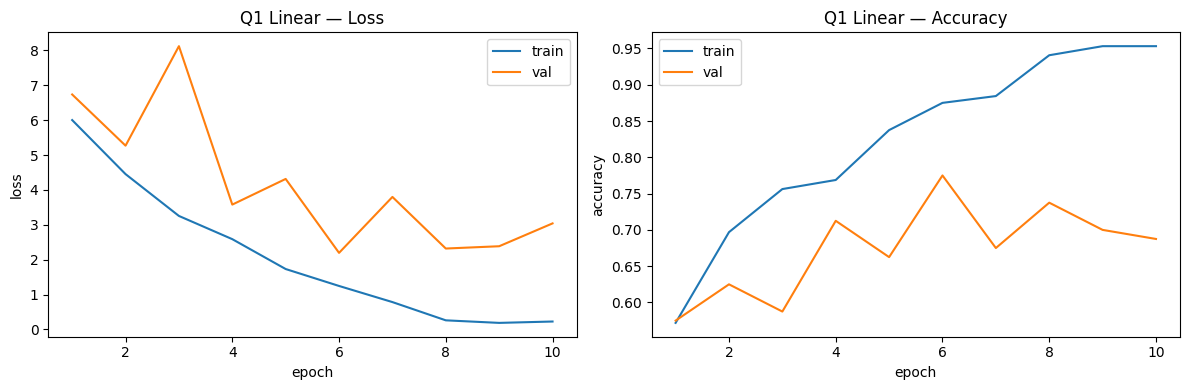


Q1 — Best validation top-1 accuracy: 0.7750


In [41]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"],   label="val")
axes[0].set_title("Q1 Linear — Loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="train")
axes[1].plot(epochs_range, history["val_acc"],   label="val")
axes[1].set_title("Q1 Linear — Accuracy")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()


best_val_acc = max(history["val_acc"])
print(f"\nQ1 — Best validation top-1 accuracy: {best_val_acc:.4f}")


### 2. Q2 . Create a CNN with One Convolutional Block.
Resize to 128×128 , normalize; 
model: Conv2d(3→32, 3×3, padding=1) → MaxPool2d(2×2) → Flatten → Linear(num_classes) → Softmax . 
Keep the same preprocessing   as Q1.  

In [42]:
class CNNOneBlock(nn.Module):
    def __init__(self, img_size=IMG_SIZE, num_classes=NUM_CLASSES):
        super().__init__()
        self.conv = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(32 * (img_size // 2) * (img_size // 2), num_classes)

    def forward(self, x):
        x = self.pool(self.conv(x))
        return self.linear(self.flatten(x))

In [46]:
q2_model = CNNOneBlock()
# here i dont do any preprocessing because normalization in this step is the same as before

print(q2_model)
print(f"Parameters: {sum(p.numel() for p in q2_model.parameters()):,}")

CNNOneBlock(
  (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=131072, out_features=2, bias=True)
)
Parameters: 263,042


### 3. Q3. Add Activation Functions to the Conv Block.  Insert ReLU  after the convolution:  
Conv2d (3→32, 3×3, padding=1)  → ReLU → MaxPool2d(2×2) → Flatten → Linear (to 
num_classes) → Softmax.